# GPT2 from scratch

This notebook is a step by step implementation of a GPT-2 model from scratch using PyTorch. It also works for GPT-3 since GPT-3 is mostly a scaled-up version of GPT-2.

In [40]:
# TODO: visualize attention post training
# TODO: visualize gradient issues
# TODO: without bias?
# TODO: make sampling faster
# TODO: how to measure model quality?
# TODO: karpathy tokenizer video
# TODO: add validation set / step
# TODO: load gpt 2 checkpoint 

from aiml_notebooks import (
    estimate_training_memory_gb,
    print_memory_estimate,
    find_max_batch_size,
    free_memory,
    show_memory_usage,
    load_pretrained_gpt2_weights,
    track_block_activations,
)

BASE_CONFIG = {
    "n_positions": 64, # TODO: call block_size
    "batch_size": 64, #2048 *2, #128,,  # Reduced from 512 to fit in 16GB
    "n_embd": 64,
    "n_head": 2,
    "n_layer": 2,
    "learning_rate": 3e-3,
    #"dropout": 0.1,
    "gradient_accumulation_steps": 8,  # 64 * 8 = 512 effective batch size
    "tune_batch_size": False,
    "layer_norm_enabled": True,
    "tokenizer": "char",
    "n_epochs": 100
}

# Update
GPT2_CONFIG = {
    **BASE_CONFIG,
     "n_embd": 768,
      "n_layer": 12,        # Currently 6, needs to be 12
      "n_head": 12,
      "n_positions": 1024,  # Currently 256, needs to be 1024
      "tokenizer": "gpt2"
}

# Update
GPT3_CONFIG = {
    **BASE_CONFIG,
    "n_embd": 4096,
    "n_layer": 96,
    "n_head": 96,
    "n_positions": 1024,
    "tokenizer": "gpt2"
}

CONFIG = {
    **BASE_CONFIG,
    #**GPT2_CONFIG
    #**GPT3_CONFIG
}

Select training device:

In [41]:
import torch
DEVICE = torch.device("mps")

Load dataset:

In [42]:
with open("data/lotr_clean.txt", "r", encoding="utf-8") as f: DATASET_TEXT = f.read()
DATASET_TEXT[:10000]

'PROLOGUE\n\n1. Concerning Hobbits\n\nThis book is largely concerned with Hobbits, and from its pages a reader may discover much of their character and a little of their history. Further information will also be found in the selection from the Red Book of Westmarch that has already been published, under the title of The Hobbit. That story was derived from the earlier chapters of the Red Book, composed by Bilbo himself, the first Hobbit to become famous in the world at large, and called by him There and Back Again, since they told of his journey into the East and his return: an adventure which later involved all the Hobbits in the great events of that Age that are here related.\nMany, however, may wish to know more about this remarkable people from the outset, while some may not possess the earlier book. For such readers a few notes on the more important points are here collected from Hobbit-lore, and the first adventure is briefly recalled.\n\nHobbits are an unobtrusive but very ancien

In [43]:
chars = sorted(list(set(DATASET_TEXT)))
len(chars), chars

(87,
 ['\n',
  ' ',
  '!',
  '"',
  "'",
  '(',
  ')',
  ',',
  '-',
  '.',
  '/',
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  ':',
  ';',
  '=',
  '?',
  'A',
  'B',
  'C',
  'D',
  'E',
  'F',
  'G',
  'H',
  'I',
  'J',
  'K',
  'L',
  'M',
  'N',
  'O',
  'P',
  'Q',
  'R',
  'S',
  'T',
  'U',
  'V',
  'W',
  'X',
  'Y',
  'Z',
  'a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z',
  'Ó',
  'á',
  'â',
  'ä',
  'é',
  'ë',
  'í',
  'ó',
  'ú',
  'û'])

Create tokenizer:

In [44]:
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {i:c for i, c in enumerate(chars)}
encode = lambda text: [ctoi[c] for c in text]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world")), encode("hello world"), len(ctoi)

('hello world', [58, 55, 62, 62, 65, 1, 73, 65, 68, 62, 54], 87)

Wrap tokenizer in a class:

In [45]:
class CharacterTokenizer:
    def __init__(self, text):
        self.chars = sorted(list(set(text)))
        self.ctoi = {c:i for i, c in enumerate(self.chars)}
        self.itoc = {i:c for i, c in enumerate(self.chars)}
        
    def encode(self, text):
        return [self.ctoi[c] for c in text]
    
    def decode(self, tokens):
        return "".join([self.itoc[i] for i in tokens])

    def get_vocab_size(self):
        return len(self.ctoi) + 1

    def get_pad_id(self):
        return len(self.ctoi)


Test GPT2 tokenizer (subword tokenizer):

In [46]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
encode = tokenizer.encode
decode = tokenizer.decode
decode(encode("hello world")), encode("hello world")

('hello world', [31373, 995])

Wrap GPT2 tokenizer in a class with same interface as the character tokenizer:

In [47]:
class GPT2Tokenizer:
    def __init__(self, text):
        self.tokenizer = tiktoken.get_encoding("gpt2")
        
    def encode(self, text):
        return self.tokenizer.encode(text)
    
    def decode(self, tokens):
        return self.tokenizer.decode(tokens)

    def get_vocab_size(self):
        return self.tokenizer.n_vocab + 1

    def get_pad_id(self):
        return self.tokenizer.n_vocab
        

Instantiate the chosen tokenizer:

In [48]:
tokenizer_cls = GPT2Tokenizer if CONFIG["tokenizer"] == "gpt2" else CharacterTokenizer
TOKENIZER = tokenizer_cls(DATASET_TEXT)

Create token embedding table:

In [49]:
import torch
import torch.nn as nn

# Retrieve params
n_embd = CONFIG["n_embd"]
n_positions = CONFIG["n_positions"]
pad_id = TOKENIZER.get_pad_id()
vocab_size = TOKENIZER.get_vocab_size() 

# Encode and pad to max sequence length
tokens = TOKENIZER.encode("hello")
pad = lambda tokens: tokens + [pad_id] * (n_positions - len(tokens))
tokens = pad(tokens)
padded = torch.tensor(tokens)

# Create token embedding table (lookup table of with token ids as keys and embeddings as values)
# embeddings are random initialized and then tuned during training
token_embedding_table = nn.Embedding(vocab_size, n_embd)

# Embed tokens
tokens_emb = token_embedding_table(padded)
tokens_emb.shape, tokens_emb

(torch.Size([64, 64]),
 tensor([[ 1.1009, -1.1676, -0.0994,  ...,  0.5595, -0.5375,  0.3129],
         [-1.7109, -0.9240, -0.6571,  ..., -0.6936, -0.8258,  0.4412],
         [ 2.6058, -0.9468,  0.4253,  ...,  0.8015, -0.8824,  0.9894],
         ...,
         [-0.3197,  0.4032,  0.3337,  ...,  0.6447,  1.2482, -1.1486],
         [-0.3197,  0.4032,  0.3337,  ...,  0.6447,  1.2482, -1.1486],
         [-0.3197,  0.4032,  0.3337,  ...,  0.6447,  1.2482, -1.1486]],
        grad_fn=<EmbeddingBackward0>))

Create position embedding table:

In [50]:
# Retrieve params
n_positions = CONFIG["n_positions"]
n_embd = CONFIG["n_embd"]

# Create position embedding table (lookup table of with position ids as keys and embeddings as values)
# embeddings are random initialized and then tuned during training
position_embedding_table = nn.Embedding(n_positions, n_embd)

# Retrieve embeddings for all positions
positions = torch.arange(n_positions)
positions_emb = position_embedding_table(positions)
positions_emb.shape, positions_emb

(torch.Size([64, 64]),
 tensor([[-1.1632e-01, -1.5017e+00,  1.7790e+00,  ..., -3.5118e-01,
           9.5761e-02,  6.0973e-01],
         [-4.4062e-01,  4.9781e-01,  9.1486e-01,  ...,  1.7947e+00,
           3.0854e-01,  1.8251e-01],
         [ 4.1177e-01, -5.5843e-01, -3.5086e-01,  ...,  2.3684e-01,
           9.5518e-02,  2.0232e+00],
         ...,
         [ 9.3660e-01,  7.3370e-01,  1.8753e+00,  ...,  3.0614e-01,
           1.3761e+00,  1.0500e+00],
         [ 4.7671e-01,  8.9228e-01, -1.0321e+00,  ...,  1.9741e+00,
          -1.1716e-01, -9.0838e-01],
         [-2.0048e-01,  1.6836e+00,  8.4072e-01,  ...,  1.9964e-03,
           1.6131e-01,  1.4050e+00]], grad_fn=<EmbeddingBackward0>))

Test combining token embeddings and positions embeddings:

In [51]:
x = tokens_emb + positions_emb
x.shape, x

(torch.Size([64, 64]),
 tensor([[ 0.9846, -2.6693,  1.6796,  ...,  0.2083, -0.4418,  0.9226],
         [-2.1515, -0.4262,  0.2578,  ...,  1.1011, -0.5172,  0.6237],
         [ 3.0175, -1.5052,  0.0745,  ...,  1.0383, -0.7869,  3.0126],
         ...,
         [ 0.6169,  1.1369,  2.2089,  ...,  0.9509,  2.6242, -0.0986],
         [ 0.1570,  1.2955, -0.6984,  ...,  2.6188,  1.1310, -2.0570],
         [-0.5202,  2.0868,  1.1744,  ...,  0.6467,  1.4095,  0.2564]],
        grad_fn=<AddBackward0>))

Create simple batch sampler:

In [52]:
DATASET_TOKENS = TOKENIZER.encode(DATASET_TEXT)

def sample_batch(batch_len, n_positions=CONFIG["n_positions"]):
    xs, ys = [], []
    for _ in range(batch_len):
        offset_idx = torch.randint(len(DATASET_TOKENS) - n_positions, (1,))
        x = DATASET_TOKENS[offset_idx:offset_idx+n_positions]
        y = DATASET_TOKENS[offset_idx+1:offset_idx+n_positions+1]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs), torch.tensor(ys)

x, y = sample_batch(10)
x.shape, x, y.shape, y

(torch.Size([10, 64]),
 tensor([[51, 64, 57, 55,  7,  1, 51, 64, 54,  1, 69, 65, 63, 55, 58, 65, 73,  1,
          71, 64, 66, 62, 55, 51, 69, 51, 64, 70,  9,  1, 32, 55,  1, 53, 65, 71,
          62, 54,  1, 64, 65, 70,  1, 63, 51, 61, 55,  1, 65, 71, 70,  1, 73, 58,
          51, 70,  1, 59, 70,  1, 69, 51, 59, 54],
         [68,  1, 51, 57, 51, 59, 64,  1, 58, 51, 72, 55,  1, 70, 58, 55,  1, 53,
          65, 71, 68, 51, 57, 55,  1, 70, 65,  1, 62, 55, 51, 72, 55,  1, 70, 58,
          55,  1, 69, 51, 56, 55, 70, 75,  1, 65, 56,  1, 70, 58, 55, 69, 55,  1,
          69, 70, 65, 64, 55,  1, 73, 51, 62, 62],
         [64, 55,  1, 51, 64, 54,  1, 70, 58, 55, 75,  1, 73, 55, 68, 55,  1, 52,
          65, 71, 64, 54,  1, 59, 64,  1, 70, 58, 55,  1, 55, 64, 54,  1, 70, 65,
           1, 69, 70, 68, 59, 61, 55,  1, 70, 58, 55,  1, 42, 65, 51, 54,  9,  1,
          44, 58, 55, 59, 68,  1, 70, 58, 65, 71],
         [56, 55, 62, 70,  1, 51,  1, 57, 68, 55, 51, 70,  1, 73, 55, 51, 68, 59,
    

Test decoding batch:

In [53]:
for i in range(x.shape[0]):
    x_tokens = x[i].tolist()
    y_tokens = y[i].tolist()
    print(f"x {i}: {TOKENIZER.decode(x_tokens)}")
    print(f"y {i}: {TOKENIZER.decode(y_tokens)}")
    print()

x 0: ange, and somehow unpleasant. He could not make out what it said
y 0: nge, and somehow unpleasant. He could not make out what it said,

x 1: r again have the courage to leave the safety of these stone wall
y 1:  again have the courage to leave the safety of these stone walls

x 2: ne and they were bound in the end to strike the Road. Their thou
y 2: e and they were bound in the end to strike the Road. Their thoug

x 3: felt a great weariness come over him. Ever since the sun began t
y 3: elt a great weariness come over him. Ever since the sun began to

x 4: w. A Barrow-wight had taken him, and he was probably already und
y 4: . A Barrow-wight had taken him, and he was probably already unde

x 5: call every memory of his former journey in the Mines, and consid
y 5: all every memory of his former journey in the Mines, and conside

x 6: that wound its way among the ruined walls and paving-stones of a
y 6: hat wound its way among the ruined walls and paving-stones of an

x 7: ire. It 

Test sampling batch and performing full embedding (token + position embeddings): 

In [54]:
n_positions = CONFIG["n_positions"]
x, _ = sample_batch(1)
x_emb = token_embedding_table(x)
positions = torch.arange(n_positions)
pos_emb = position_embedding_table(positions)
x = x_emb + pos_emb
x.shape, x[0][0]

(torch.Size([1, 64, 64]),
 tensor([-0.1866, -1.5017,  0.0800,  0.0616, -1.4915, -0.0708,  0.9574,  2.0695,
          0.8329,  3.3633,  0.3916, -1.7021,  0.2373, -0.1409, -1.4723, -0.0315,
         -1.4444,  0.0650,  1.5572,  1.1397, -0.8993, -0.4723,  2.4934, -0.6840,
         -1.7115, -1.1693,  0.7629,  0.4932,  0.9973, -0.9835,  0.1329, -1.8698,
         -1.4522,  0.4256, -0.1484,  1.8004,  0.0707,  2.4198,  1.4812,  1.1052,
         -0.2114,  0.5977, -1.5209, -0.5310,  0.6207, -0.5859, -0.3871, -0.7384,
          1.3216,  1.4967,  0.1870,  1.0454, -1.7345, -1.8403,  0.4498, -0.6708,
         -0.8015, -1.8284, -3.5001, -1.5603,  1.7947,  0.6785,  0.7767,  1.4245],
        grad_fn=<SelectBackward0>))

Create QKV weight matrices:

In [55]:
qkv_shape = (CONFIG["n_embd"], CONFIG["n_embd"])
Wq = torch.randn(qkv_shape)
Wk = torch.randn(qkv_shape)
Wv = torch.randn(qkv_shape)

Create the Q, K, V matrices by multiplying the input by the corresponding weight matrices:

In [56]:
Q = x @ Wq
K = x @ Wk
V = x @ Wv
Q.shape, K.shape, V.shape

(torch.Size([1, 64, 64]), torch.Size([1, 64, 64]), torch.Size([1, 64, 64]))

Attempt to transpose K so we can later perform a dot product with Q:

In [57]:
Kt = K.transpose(-2, -1)
Kt.shape

torch.Size([1, 64, 64])

Perform dot product with Q and K:

In [58]:
QKt = Q @ Kt # (B, T, C) @ (B, C, T) -> (B, T, T)
QKt.shape, QKt[0][0]

(torch.Size([1, 64, 64]),
 tensor([ -337.6608,    63.2262,   385.1238,   -94.3697, -1128.1400,   357.3308,
           502.9829,   267.6270,   877.7194, -1045.7765,  -694.1212,  -330.0844,
          1589.5449,   448.5220,  -455.2438,  1496.4302,  -635.5761,   324.6228,
           299.1334,  -544.5450,  -231.3340,   462.9898,  -383.3562,  -129.6832,
          -269.8805, -1495.4702,  -868.7981, -1121.2881,  -855.1608,  -709.7104,
           682.8343,  -202.8463,   599.5472, -1238.2582,  -808.1244,   167.3579,
           805.9878,   772.6201,  -522.4968,   373.1170,  1036.3427,   247.6175,
          -724.9251,   -16.3297,   -19.0990,   597.9126,  -357.7020,   527.8975,
          1287.0560,   355.4672,  1303.1781,   822.8682,   178.4616,  -450.6247,
          -164.3787,    38.7056,  -718.0741,  -459.5689,  -404.9915,   -43.2213,
         -1360.7037,   417.5862,    48.8882,  -814.1926],
        grad_fn=<SelectBackward0>))

Scale the QKt matrix by the square root of the head size (embedding size for single head). This is done to stabilize the softmax operation, otherwise it could easily result in one hot vectors due to the large values in QKt.

In [59]:
QKt_scaled = QKt / torch.sqrt(torch.tensor(n_embd))
QKt_scaled.shape, QKt_scaled[0][0]

(torch.Size([1, 64, 64]),
 tensor([ -42.2076,    7.9033,   48.1405,  -11.7962, -141.0175,   44.6663,
           62.8729,   33.4534,  109.7149, -130.7221,  -86.7652,  -41.2605,
          198.6931,   56.0653,  -56.9055,  187.0538,  -79.4470,   40.5779,
           37.3917,  -68.0681,  -28.9167,   57.8737,  -47.9195,  -16.2104,
          -33.7351, -186.9338, -108.5998, -140.1610, -106.8951,  -88.7138,
           85.3543,  -25.3558,   74.9434, -154.7823, -101.0155,   20.9197,
          100.7485,   96.5775,  -65.3121,   46.6396,  129.5428,   30.9522,
          -90.6156,   -2.0412,   -2.3874,   74.7391,  -44.7127,   65.9872,
          160.8820,   44.4334,  162.8973,  102.8585,   22.3077,  -56.3281,
          -20.5473,    4.8382,  -89.7593,  -57.4461,  -50.6239,   -5.4027,
         -170.0880,   52.1983,    6.1110, -101.7741], grad_fn=<SelectBackward0>))

Create a triangular mask of the size of QKt, we'll need it to mask future tokens to force causal language modeling:

In [60]:
mask = torch.tril(torch.ones((n_positions, n_positions))).bool()
mask

tensor([[ True, False, False,  ..., False, False, False],
        [ True,  True, False,  ..., False, False, False],
        [ True,  True,  True,  ..., False, False, False],
        ...,
        [ True,  True,  True,  ...,  True, False, False],
        [ True,  True,  True,  ...,  True,  True, False],
        [ True,  True,  True,  ...,  True,  True,  True]])

Now let's mask the future tokens so that each token can only attend to previous tokens in the sequence:

In [61]:
QKt_scaled_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
QKt_scaled_masked.shape, QKt_scaled_masked[0]

(torch.Size([1, 64, 64]),
 tensor([[ -42.2076,      -inf,      -inf,  ...,      -inf,      -inf,
               -inf],
         [ 164.3153,  127.0812,      -inf,  ...,      -inf,      -inf,
               -inf],
         [ 218.6328,  -42.2825,   24.7986,  ...,      -inf,      -inf,
               -inf],
         ...,
         [  87.3236,  -71.7738,   95.5503,  ...,   -6.6076,      -inf,
               -inf],
         [ -14.7582,  -17.2220,  -57.9653,  ..., -217.5418,   69.1567,
               -inf],
         [ -38.7210,  -27.6981,   57.6877,  ...,  -15.4950, -128.1777,
            -6.9407]], grad_fn=<SelectBackward0>))

Visualize current attention matrix, its random so it wont mean much, but the upper right triangle should all be the same color:

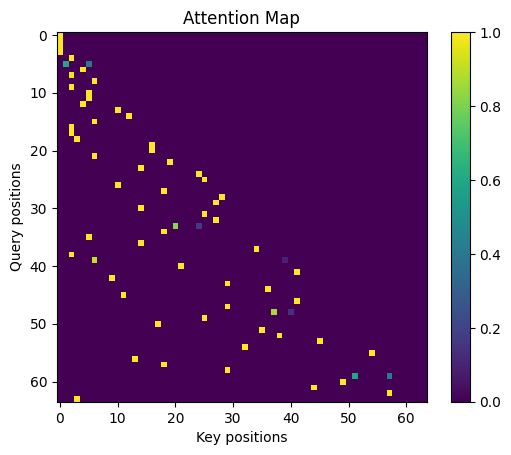

In [62]:
from torch.nn import functional as F
import matplotlib.pyplot as plt

attention = F.softmax(QKt_scaled_masked, dim=-1)

plt.imshow(attention[0].detach().cpu(), cmap='viridis')
plt.colorbar()
plt.title("Attention Map")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

Now that the attention mask is computed we can use it to scale the V tensor. The result of this operation will be the meaning of each pair of words scaled by how much they are relevant to each other in this sentence.

In [63]:
output = attention @ V
output.shape

torch.Size([1, 64, 64])

Let's wrap all that we've done in an attention head class:

In [64]:
class AttentionHead(nn.Module):
    def __init__(
        self, 
        head_size,
        n_positions=CONFIG["n_positions"], 
        n_embd=CONFIG["n_embd"], 
    ):
        nn.Module.__init__(self)
        
        # If head_size is not provided, use the embedding size 
        # (assume single head in transformer block)
        if head_size is None: head_size = n_embd
        self.head_size = head_size

        # Create the weight matrices for the query, key and value
        self.W_q = nn.Linear(n_embd, head_size)
        self.W_k = nn.Linear(n_embd, head_size)
        self.W_v = nn.Linear(n_embd, head_size)

        # Create the causal mask and register as a buffer so it's not a parameter (not trainable)
        self.register_buffer("mask", ~torch.tril(torch.ones(n_positions, n_positions)).bool())
        
    def forward(self, x):
        B, T, C = x.shape
        
        # Project the input into the query, key and value spaces
        # (B, T, C) -> (B, T, head_size)
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Matrix multiply the query and key matrices to get the attention scores
        # (how close each query is to each key)
        # (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt

        # Scale the attention scores by the square root of the head size
        # (keep attention scores from exploding otherwise softmax will 
        # saturate and create one hot vectors)
        # (B, T, T) / sqrt(head_size) -> (B, T, T)
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size))

        # Mask the future tokens so that each token can only attend to previous tokens
        # (B, T, T) -> (B, T, T)
        mask = self.mask[:T, :T].to(x.device)
        QKt_masked = QKt_scaled.masked_fill(mask, float("-inf"))

        # Create the attention weights by applying a softmax to the masked attention scores
        # (B, T, T) -> (B, T, T)
        attention = F.softmax(QKt_masked, dim=-1)

        # Map the attention weights to the value space
        # in order to create an output with the same shape as the input (batch, time, channels)
        # but now with the actual meaning of each word (eg: "the" can now have an embedding of "cat" when input is "the cat jumped")
        # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)
        out = attention @ V

        # Return the output
        return out

# Run a batch through the attention head
with torch.no_grad():
    x, y = sample_batch(1)
    x = token_embedding_table(x)
    out = AttentionHead(CONFIG["n_embd"] // 2)(x)
out.shape, out

(torch.Size([1, 64, 32]),
 tensor([[[-4.4438e-01,  7.8028e-01, -7.5909e-02,  ..., -6.8128e-01,
           -2.8445e-01,  1.1126e-01],
          [-1.3160e-01, -2.6203e-01,  1.1116e+00,  ..., -9.2268e-02,
            1.1166e-01,  1.6878e-01],
          [ 7.7687e-02, -2.2822e-01,  1.0203e+00,  ...,  2.0884e-01,
            1.6488e-01,  2.5252e-01],
          ...,
          [ 6.1132e-02,  2.0581e-01, -2.2653e-01,  ..., -8.6322e-02,
           -1.9431e-01,  1.4915e-01],
          [ 1.0478e-01,  1.9770e-01, -9.9975e-02,  ..., -1.1476e-01,
           -8.7039e-02,  7.0549e-02],
          [ 1.3367e-01,  2.4867e-01,  1.0083e-03,  ..., -1.3439e-01,
           -4.9536e-02,  6.4309e-02]]]))

Create a class that bundles N attention heads into a single construct that forwards the input through all heads and concatenates the outputs back
into a single tensor of the same shape as the input.

In [65]:
class MultiHeadAttention(nn.Module):
    def __init__(self, 
        n_heads=CONFIG["n_head"], 
        n_embd=CONFIG["n_embd"],
    ):
        nn.Module.__init__(self)
        
        # Create the N attention heads
        head_size = n_embd // n_heads
        self.heads = nn.ModuleList([AttentionHead(head_size) for _ in range(n_heads)])

        # Create the weight matrix that will project the concatenated 
        # outputs back into the same shape to allow the model to learn 
        # to mix the outputs of each head (otherwise each head could only 
        # influence a section of the resulting embedding)
        self.W_o = nn.Linear(n_embd, n_embd)

    def forward(self, x):
        # Run the input through all heads and collect the outputs
        outs = []
        for head in self.heads: # TODO: vectorize this?
            out = head(x)
            outs.append(out)

        # Concatenate the outputs of all heads back into the original shape
        # [(B, T, head_size) for _ in range(n_heads)] -> (B, T, n_heads * head_size)
        mha_out = torch.concat(outs, dim=-1)

        # Project the concatenated outputs back into the same shape as the input
        # (this allows the model to learn to mix the outputs of each head)
        mha_out = self.W_o(mha_out)
        return mha_out

# Run a batch through the multi-head attention
with torch.no_grad():
    x, _ = sample_batch(1)
    x = token_embedding_table(x)
    out = MultiHeadAttention(n_heads=2)(x)
out.shape, out

(torch.Size([1, 64, 64]),
 tensor([[[ 0.1590,  0.7014, -0.3312,  ...,  0.2681, -0.1580,  0.0227],
          [-0.0753,  0.3536, -0.1243,  ...,  0.1471,  0.2571,  0.0987],
          [ 0.0696,  0.5024,  0.1078,  ...,  0.3829,  0.0135,  0.1469],
          ...,
          [ 0.0787,  0.2732, -0.1511,  ...,  0.1775,  0.0492,  0.0041],
          [ 0.1604,  0.3660, -0.0312,  ...,  0.3043,  0.0341,  0.0059],
          [ 0.0514,  0.3036, -0.0774,  ...,  0.2445,  0.1046,  0.0031]]]))

Now let's create a faster attention implementation that does exactly the same thing but with less tensor operations by packing the Q, K, V matrices into a single tensor and then packing all heads into a single tensor as well, this will drastically reduce the number of operations and speed up the computation.

In [66]:
class FastMultiHeadAttention(nn.Module):
    def __init__(
        self, 
        n_heads,
        n_embd=CONFIG["n_embd"],
        block_size=CONFIG["n_positions"]
    ):
        nn.Module.__init__(self)
        head_size = n_embd // n_heads
        self.n_heads = n_heads
        self.head_size = head_size
        
        # Create single tensor with all weights for Q, K, V
        self.W_qkv = nn.Linear(n_embd, n_embd * 3)
        
        # Create the weight matrix that will project the concatenated 
        # outputs back into the same shape to allow the model to learn 
        # to mix the outputs of each head (otherwise each head could only 
        # influence a section of the resulting embedding)
        self.W_o = nn.Linear(n_embd, n_embd)

        # Create the causal mask and register as a buffer so it's not a parameter (not trainable)
        self.register_buffer("mask", ~torch.tril(torch.ones(block_size, block_size)).bool())

    def forward(self, x):
        B, T, C = x.shape

        # Project the input into the query, key and value spaces
        # (B, T, C) -> (B, T, 3 * n_embd)
        QKV = self.W_qkv(x)

        # Split the concatenated Q, K, V into separate tensors
        # (B, T, 3 * n_embd) -> [(B, T, n_embd) for _ in range(3)]
        Q, K, V = torch.chunk(QKV, 3, dim=-1)

        # Reshape the tensors to split the embedding dimension into multiple heads
        # (B, T, n_embd) -> (B, T, n_heads, head_size)
        Q = Q.view(B, T, self.n_heads, self.head_size)
        K = K.view(B, T, self.n_heads, self.head_size)
        V = V.view(B, T, self.n_heads, self.head_size)

        # Transpose the tensors so that the head dimension is first 
        # (B, T, n_heads, head_size) -> (B, n_heads, T, head_size)
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # Matrix multiply the query and key matrices to get the attention scores
        # (B, n_heads, T, head_size) @ (B, n_heads, head_size, T) -> (B, n_heads, T, T)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt

        # Scale the attention scores by the square root of the head size
        # (keep attention scores from exploding otherwise softmax will 
        # saturate and create one hot vectors)
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size)).to(x.device)

        # Mask the future tokens so that each token can only attend to previous tokens
        mask = self.mask[:T, :T].unsqueeze(0).unsqueeze(0).to(x.device) # TODO: send to device earlier?
        QKt_masked = QKt_scaled.masked_fill(mask, float("-inf"))

        # Apply the softmax to the masked attention scores
        # (B, n_heads, T, T) -> (B, n_heads, T, T)
        attention = F.softmax(QKt_masked, dim=-1)

        # Matrix multiply the attention scores with the value matrix to get the output
        # (B, n_heads, T, T) @ (B, n_heads, T, head_size) -> (B, n_heads, T, head_size)
        V_scaled = attention @ V

        # Transpose the output so that the head dimension is last
        # (B, n_heads, T, head_size) -> (B, T, n_heads, head_size)
        V_scaled_t = V_scaled.transpose(1, 2)

        # Reshape the output to concatenate the heads back into the original shape
        # (B, T, n_heads, head_size) -> (B, T, n_embd)
        V_scaled_t_realigned = V_scaled_t.contiguous().view(B, T, C)

        # Project the concatenated outputs back into the same shape as the input
        # (this allows the model to learn to mix the outputs of each head)
        output = self.W_o(V_scaled_t_realigned) 

        # Return the multi-head attention output
        return output

# Run a batch through the fast multi-head attention
with torch.no_grad():
    x, _ = sample_batch(1)
    x = token_embedding_table(x)
    out = FastMultiHeadAttention(2)(x)
    out.shape, out

Now let's create the feedforward network that follows the attention layer in the transformer block. The FFN layer should scale the input up by 4x, apply a non-linearity and then scale it back down to the original dimensions.

In [67]:
ffn1 = nn.Linear(n_embd, n_embd * 4)
gelu = nn.GELU()
ffn2 = nn.Linear(n_embd * 4, n_embd)
n_heads = CONFIG["n_head"]
head_size = n_embd // n_heads
lm_head = nn.Linear(n_embd, head_size)
output_head = lm_head(ffn2(gelu(ffn1(output))))
output_head.shape, output_head

(torch.Size([1, 64, 32]),
 tensor([[[-1.9150, -2.1291,  1.4674,  ..., -1.3691, -4.2460,  2.4341],
          [-1.9150, -2.1291,  1.4674,  ..., -1.3691, -4.2460,  2.4341],
          [-1.9150, -2.1291,  1.4674,  ..., -1.3691, -4.2460,  2.4341],
          ...,
          [ 2.3249, -4.4157,  0.1751,  ...,  0.2850,  0.3295,  0.5839],
          [ 1.9348, -5.2709, -1.1199,  ..., -0.1888, -0.7563,  1.7093],
          [ 1.0782, -3.7693, -0.8258,  ...,  1.4615, -0.8740,  2.9746]]],
        grad_fn=<ViewBackward0>))

Wrap the FFN in a class:

In [68]:
class FeedForward(nn.Module):
    def __init__(self, n_embd=CONFIG["n_embd"]):
        nn.Module.__init__(self)
        
        self.ffn1 = nn.Linear(n_embd, n_embd * 4)
        self.gelu = nn.GELU(approximate='tanh')  # TODO: hugging face does this... why?
        self.ffn2 = nn.Linear(n_embd * 4, n_embd)

    def forward(self, x):
        x = self.ffn1(x)
        x = self.gelu(x)
        x = self.ffn2(x)
        return x

# Run a batch through the feedforward network
with torch.no_grad():
    x,y = sample_batch(1)
    x = token_embedding_table(x)
    mha_out = MultiHeadAttention()(x)
    out = FeedForward()(mha_out)
    out.shape, out

Now that we have all the components of a transformer block, let's wrap them in a class:

In [69]:
class TransformerBlock(nn.Module):
    def __init__(
        self, 
        n_embd=CONFIG["n_embd"], 
        n_heads=CONFIG["n_head"], 
        layer_norm_enabled=CONFIG["layer_norm_enabled"]
    ):
        nn.Module.__init__(self)
        self.head = FastMultiHeadAttention(n_heads)
        self.ffn = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd) if layer_norm_enabled else nn.Identity()
        self.ln2 = nn.LayerNorm(n_embd) if layer_norm_enabled else nn.Identity()

    def forward(self, x):
        # Normalize the input features, run them through the 
        # attention layer and then add the input (residual connection)
        x = x + self.head(self.ln1(x))

        # Normalize the input features, run them through the 
        # feedforward network and then add the input (residual connection)
        x = x + self.ffn(self.ln2(x))

        # Return the transformed features
        return x

# Run a batch through the transformer block
with torch.no_grad():
    x, y = sample_batch(1)
    x = token_embedding_table(x)
    out = TransformerBlock()(x)
out.shape, out

(torch.Size([1, 64, 64]),
 tensor([[[ 0.8377, -0.5605, -0.7645,  ..., -0.7380, -1.5779,  0.7917],
          [ 3.1308, -0.9715,  0.7618,  ...,  0.6568, -0.7884,  1.6908],
          [-1.3002, -1.3762, -0.4983,  ..., -0.5685, -0.2822,  0.6981],
          ...,
          [ 1.5701, -0.2002,  1.6023,  ..., -0.9072,  1.7269, -1.1436],
          [-1.6351, -1.4141, -0.5831,  ..., -0.5501, -0.4331,  0.2965],
          [-1.6239, -1.4136, -0.5829,  ..., -0.5514, -0.4241,  0.2949]]]))

Now that we have the transformer block, let's create the entire transformer model (decoder only):

In [70]:
class Transformer(nn.Module):
    def __init__(
        self,
        vocab_size=TOKENIZER.get_vocab_size(),
        n_embd=CONFIG["n_embd"], 
        n_layer=CONFIG["n_layer"], 
        n_positions=CONFIG["n_positions"]
    ):
        nn.Module.__init__(self)

        # Create the token embedding table (maps tokens to learnable embeddings)
        # (B, T) -> (B, T, C)
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)

        # Create the position embedding table (maps positions to learnable embeddings)
        # (T,) -> (T, C)
        self.position_embedding_table = nn.Embedding(n_positions, n_embd)

        # Create the transformer blocks
        self.blocks = nn.ModuleList([TransformerBlock() for _ in range(n_layer)])

        # Create the language model head (maps the final layer to the vocabulary size) 
        # (B, T, C) -> (B, T, vocab_size)
        self.lm_head = nn.Linear(n_embd, vocab_size)
        
        # TODO: hugging face does this... why?
        self.lm_head.weight = self.token_embedding_table.weight  # Share weights!

        # Create the final layer normalization (normalizes the output of the last transformer block)
        # (B, T, C) -> (B, T, C)
        self.ln_final = nn.LayerNorm(n_embd) if CONFIG["layer_norm_enabled"] else nn.Identity()

    def forward(self, x):
        B, T = x.shape

        # Create token embeddings
        # (B, T) -> (B, T, C)
        tok_emb = self.token_embedding_table(x)

        # Create position embeddings and unsqueeze 
        # them to align with the token embeddings
        # (T,) -> (T, C) -> (1, T, C)
        pos = torch.arange(T, device=x.device)
        pos_emb = self.position_embedding_table(pos)
        pos_emb = pos_emb.unsqueeze(0)

        # Add the token embeddings and 
        # position embeddings to create the input
        x = tok_emb + pos_emb

        # Run the input through all transformer blocks
        for block in self.blocks: x = block(x)

        # Project the output to the vocabulary size
        # Normalize the output of the last transformer block and feed it through the language model head
        # to project to the vocabulary size
        # (B, T, C) -> (B, T, vocab_size)
        x = self.lm_head(self.ln_final(x))

        # Return the projected output
        return x

    @torch.no_grad()
    def generate(self, text, max_len=20):
        device = next(self.parameters()).device
        n_positions = CONFIG["n_positions"]
        tokens = encode(text)
        #tokens = pad(tokens)
        tokens_t = torch.tensor(tokens).to(device)
        tokens_t = tokens_t.unsqueeze(0)#view(1, -1)
        output_tokens = []
        while len(output_tokens) < max_len:
            logits = self(tokens_t)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)
            idx = idx.squeeze().item()
            tokens.append(idx)
            tokens = tokens[-n_positions:]
            tokens_t = torch.tensor(tokens).to(device).unsqueeze(0)
            #tokens_t = tokens_t.view(1, n_positions)
            output_tokens.append(idx)
        text = decode(output_tokens)
        return text

# Run a batch through the transformer
with torch.no_grad():
    x, y = sample_batch(1)
    out = Transformer()(x)
out.shape, out[0][0]

(torch.Size([1, 64, 88]),
 tensor([ 1.5834e+01, -6.7623e+00, -5.4021e+00, -1.3765e+01, -4.5500e+00,
          5.4889e+00,  1.2356e+01,  2.0057e+00, -1.2587e+00,  3.5567e+01,
          6.0841e+00,  3.9215e+00,  1.9688e+00, -1.8082e+00, -5.0774e-03,
          2.7579e+00, -6.8686e+00,  2.8585e+00,  1.5521e+00,  6.9274e+00,
          2.9455e+00,  6.4700e+00, -3.6027e+00, -8.4337e+00, -7.0797e+00,
          1.5452e-01,  5.1569e+00, -4.1133e+00, -6.0199e+00,  2.0230e+00,
          2.3856e+00,  1.7468e+00, -3.0901e-01, -1.1083e+01, -7.3933e+00,
          3.4346e+00, -2.2700e+00, -2.1188e+00,  1.6650e+00, -5.5926e+00,
          2.3750e+00,  4.6738e+00,  3.9192e+00,  9.9222e+00,  1.6823e+00,
         -8.5134e+00, -8.2617e+00,  1.4282e+00, -2.9091e+00, -8.0813e+00,
         -1.2302e+01, -8.5444e+00, -5.5127e+00, -1.0589e+01,  1.4542e+01,
         -1.7827e+00,  1.0626e+01, -5.3948e+00,  3.3631e+00,  4.1713e+00,
          4.1441e+00,  1.3912e+01, -1.8676e+00,  5.4842e+00,  9.2340e+00,
         -9.

Create the training dataset, which returns a different sequence of length `block_size` for each index in the dataset:

In [78]:
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(
        self, 
        tokens, 
        n_positions=CONFIG["n_positions"]
    ):  
        # Ensure tokens are a tensor at creation so that 
        # splitting the dataset into batches is efficient
        self.tokens = torch.tensor(tokens)
        self.n_positions = n_positions

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.n_positions]
        y = self.tokens[idx+1:idx+self.n_positions+1]
        return x, y

    def __len__(self):
        return len(self.tokens) - self.n_positions


# Test retrieving first item from the dataset
train_dataset = TrainDataset(DATASET_TOKENS)
x, y = train_dataset[100]
print("x:" + TOKENIZER.decode(x.tolist())[:10])
print("y:" + TOKENIZER.decode(y.tolist())[:10])

x:eader may 
y:ader may d


Create train data loader that iterates the dataset in random batches instead of sequential items:

In [79]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    # TODO: move to top
    num_workers=0,  # MPS doesn't benefit from >0 workers
    pin_memory=False,  # Not needed for MPS
    drop_last=True  # Ensures consistent batch sizes
)

# Test retrieving first batch from the data loader
for x, y in train_loader:
    for i in range(10):
        print("x:" + TOKENIZER.decode(x[i].tolist())[:10])
        print("y:" + TOKENIZER.decode(y[i].tolist())[:10])
        print("---")
    break

x: just as h
y:just as he
---
x: splendour
y:splendour 
---
x:ky faded.

y:y faded.
G
---
x:where we a
y:here we ar
---
x:hile more,
y:ile more, 
---
x:"
"It will
y:
"It will 
---
x:id hold of
y:d hold of 
---
x:, who had 
y: who had n
---
x:ose who wi
y:se who wie
---
x:"
"Who kno
y:
"Who know
---


Create the transformer model:

In [73]:
model = Transformer()
#model = torch.compile(model, mode="reduce-overhead") # TODO: no gain on mps?
model.to(DEVICE)
model.train()

Transformer(
  (token_embedding_table): Embedding(88, 64)
  (position_embedding_table): Embedding(64, 64)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (head): FastMultiHeadAttention(
        (W_qkv): Linear(in_features=64, out_features=192, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (ffn1): Linear(in_features=64, out_features=256, bias=True)
        (gelu): GELU(approximate='tanh')
        (ffn2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=64, out_features=88, bias=True)
  (ln_final): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
)

If `tune_batch_size` is true, find the optimal batch size and gradient accumulation steps for the model:

In [74]:
if CONFIG["tune_batch_size"]:
    from aiml_notebooks import find_optimal_batch_config
    vocab_size = TOKENIZER.get_vocab_size()
    result = find_optimal_batch_config(
        model=model,
        vocab_size=vocab_size,
        n_positions=CONFIG["n_positions"],
    )
    recommended = result['recommended']
    if CONFIG["batch_size"] == "auto": CONFIG["batch_size"] = recommended['batch_size']
    if CONFIG["gradient_accumulation_steps"] == "auto": CONFIG["gradient_accumulation_steps"] = recommended['gradient_accumulation_steps']

Create utility to measure the models' gradient norm (used to monitor training stability):

In [75]:
# Add this to your training loop to monitor gradients
def get_grad_norm(model):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)
    return total_norm

# In your training loop, after loss.backward():
grad_norm = get_grad_norm(model)
grad_norm

0.0

Create the training loop and train for `n_epochs`:

In [76]:
from tqdm import tqdm

def train(
    model, 
    n_epochs=CONFIG['n_epochs'], 
    lr=CONFIG["learning_rate"], 
    gradient_accumulation_steps=CONFIG["gradient_accumulation_steps"]
):
    # Create the optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # Initialize lists to store losses and gradient norms
    losses = []
    grad_norms = []

    # Train for `n_epochs`
    for epoch in range(n_epochs):
        # Set the model to training mode (sanity: we may have set it to evaluation mode at some point last epoch)
        model.train()

        # Zero the gradients
        optimizer.zero_grad()

        # Iterate over the training data loader
        batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
        for batch_idx, (x, y) in enumerate(batch_bar):
            # Move the batch to the device
            x, y = x.to(DEVICE), y.to(DEVICE)

            # Forward pass
            logits = model(x)

            # Permute the logits to match the shape of the targets
            # (B, T, C) -> (B, C, T)
            logits = logits.permute(0, 2, 1) # TODO: review this

            # Compute the loss
            loss = F.cross_entropy(logits, y)

            # Accumulate the loss
            losses.append(loss.item())

            # Backward pass
            # (each batch is scaled by gradient_accumulation_steps to avoid gradient explosion)
            # TODO: review this
            (loss / gradient_accumulation_steps).backward()

            # In case this is an optimization step, then adjust the model 
            # parameters based on the gradients accumulated so far
            is_optimization_step = ((batch_idx + 1) % gradient_accumulation_steps == 0) or (batch_idx + 1 == len(train_loader))
            if is_optimization_step:
                # Calculate the gradient norm 
                # (used to monitor training stability)
                grad_norm = get_grad_norm(model)
                grad_norms.append(grad_norm)
                
                # Log the loss and gradient norm
                batch_bar.set_postfix(
                    loss=f"{loss.item():.4f}",
                    grad_norm=f"{grad_norm:.4f}"
                )

                # Update the model parameters
                optimizer.step()

                # Zero the gradients so we can start accumulating gradients again
                optimizer.zero_grad()
            # In case this is not an optimization step, then just log the loss
            else:
                batch_bar.set_postfix(loss=f"{loss.item():.4f}")

    # Return the training results
    return dict(
        losses=losses,
        grad_norms=grad_norms   
    )

# Train the model for `n_epochs`
losses, grad_norms = train(model, n_epochs=CONFIG['n_epochs'])

Epoch 1/100:   1%|          | 102/15393 [00:02<05:05, 50.00it/s, loss=4.8369]                   


KeyboardInterrupt: 

Plot training losses and gradient norms:

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4)) 
axes[0].plot(losses)
axes[0].set_title("Losses")
axes[1].plot(grad_norms)
axes[1].set_title("Grad Norms")
plt.tight_layout()
plt.show()

Test generation with the trained model:

In [ ]:
model.eval()
print(model.generate("Frodo picked up the sword", max_len=1024))

Check activations of each layer:

In [ ]:
# Get a sample batch
x, y = sample_batch(1)
x = x.to(DEVICE)

# Track activations using imported utility
stats = track_block_activations(model, x, layer_norm_enabled=CONFIG["layer_norm_enabled"])

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

layers = [s['layer'] for s in stats]
max_abs = [s['max_abs'] for s in stats]
stds = [s['std'] for s in stats]

# Plot 1: Maximum absolute values (log scale)
axes[0].semilogy(max_abs, marker='o', linewidth=2, markersize=8, color='red')
axes[0].set_title('Maximum Absolute Activation Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('Max Abs Value (log scale)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(len(layers)))
axes[0].set_xticklabels(layers, rotation=45, ha='right')

# Plot 2: Standard deviation
axes[1].plot(stds, marker='s', linewidth=2, markersize=8, color='blue')
axes[1].set_title('Standard Deviation of Activations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Layer', fontsize=12)
axes[1].set_ylabel('Standard Deviation', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(len(layers)))
axes[1].set_xticklabels(layers, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("ACTIVATION STATISTICS")
print("="*70)
print(f"{'Layer':<15} {'Mean':>12} {'Std':>12} {'Max Abs':>12}")
print("-"*70)
for s in stats:
    print(f"{s['layer']:<15} {s['mean']:>12.4f} {s['std']:>12.4f} {s['max_abs']:>12.4f}")
print("="*70)

# Calculate growth rate
if len(max_abs) > 1:
    growth_rate = max_abs[-1] / max_abs[0] if max_abs[0] != 0 else float('inf')
    print(f"\nActivation Growth Rate (Final/Initial): {growth_rate:.2f}x")
    print(f"Initial max abs: {max_abs[0]:.4f}")
    print(f"Final max abs: {max_abs[-1]:.4f}")

Load pretrained weights from HuggingFace into our custom GPT-2 model:

In [ ]:
# Load pretrained GPT-2 weights from HuggingFace using imported utility
model_pretrained = Transformer().to(DEVICE)
model_pretrained = load_pretrained_gpt2_weights(model_pretrained, n_layer=CONFIG["n_layer"])

# Test generation with pretrained model
model_pretrained.eval()
print(model_pretrained.generate("Frodo picked up the sword", max_len=1024))